# 06. Nuclear vs mitochondrial genome responses to mitochondrial perturbations (report Fig. 12-17; cf. paper Fig. 6, 7D, S8)

Paper (STAR Methods p. e14):

- **K562** (genome-wide screen): perturbations of mitochondrial genes with at least 50 DEGs, at least 30 cells and
  at least 60% knockdown (268 perturbations); features are the 1,715 nuclear genes expressed at >1 UMI/cell, or
  the 13 mtDNA-encoded protein-coding genes;
- **RPE1**: at least 20 DEGs, 30 cells and 60% knockdown (140 perturbations).

Mitochondrial genes were defined with MitoCarta3.0 in the paper. MitoCarta could not be downloaded from the
compute cluster, so the union of the GO cellular-component terms starting with "Mitochondri" (GO CC 2023,
from Enrichr) is used. Heatmaps show Pearson correlations between perturbations, ordered by average-linkage
clustering (the paper ordered them by the HDBSCAN hierarchy).

Report figures: 12 and 13 (K562, nuclear and mtDNA genes), 14 (expression of the 13 mtDNA genes),
15 and 16 (RPE1, nuclear and mtDNA genes), 17 (TMEM242 in RPE1).

In [1]:
import sys; sys.path.insert(0, "../src")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import gwps

go = gwps.read_gmt(gwps.DATA / "GO_CC_2023.gmt")
mito_genes = set().union(*(g for t, g in go.items() if t.startswith("Mitochondri")))
print(f"{len(mito_genes)} mitochondrial genes (GO CC)")

# complex / category of each perturbation, used to read the heatmaps
def category(g):
    for prefix, name in [("NDUF", "Complex I"), ("SDH", "Complex II"), ("UQCR", "Complex III"), ("COX", "Complex IV"),
                         ("ATP5", "ATP synthase"), ("MRPL", "Mitoribosome"), ("MRPS", "Mitoribosome")]:
        if g.startswith(prefix):
            return name
    return "Other"

palette = {"Complex I": "#1f77b4", "Complex II": "#aec7e8", "Complex III": "#2ca02c", "Complex IV": "#98df8a",
           "ATP synthase": "#d62728", "Mitoribosome": "#9467bd", "Other": "#dddddd"}

def mito_perturbations(a, min_degs):
    o = a.obs
    keep = (o["target"].isin(mito_genes) & (o["anderson_darling_counts"] >= min_degs) &
            (o["num_cells_filtered"] >= 30) & gwps.knockdown_ok(o, 0.6))
    return o.index[keep]

def feature_sets(a):
    v = a.var
    mt = v.index[v["gene_name"].isin(gwps.MT_GENES)]
    nuclear = v.index[(v["mean"] > 1) & ~v["gene_name"].isin(gwps.MT_GENES)]
    return {"nuclear": nuclear, "mitochondrial": mt}

def within_category_r(c, cats):
    """Mean correlation between perturbations of the same complex, for complexes with >= 3 perturbations."""
    out = {}
    for k in cats.unique():
        m = (cats == k).values
        if k != "Other" and m.sum() >= 3:
            out[k] = gwps.corr_upper(c[np.ix_(m, m)]).mean()
    return pd.Series(out)

def analyse(name, label, min_degs, fig_numbers):
    a = gwps.load(name)
    sel = mito_perturbations(a, min_degs)
    cats = a.obs.loc[sel, "target"].map(category)
    print(f"{label}: {len(sel)} mitochondrial perturbations")
    summary = {}
    for (fname, genes), fig_name in zip(feature_sets(a).items(), fig_numbers):
        c = np.corrcoef(gwps.profiles(a[sel], genes).values)
        summary[f"{fname} ({len(genes)} genes)"] = within_category_r(c, cats)
        gwps.triangle_heatmap(c, cats.values, palette,
                              f"{label}: {len(sel)} mitochondrial perturbations, correlation on {len(genes)} {fname} genes", fig_name)
    return a, sel, cats, pd.DataFrame(summary).round(2)

879 mitochondrial genes (GO CC)


## Report Fig. 12, 13 (K562; cf. paper Fig. 6A, 6C) and Fig. 15, 16 (RPE1; cf. paper Fig. S8A, S8E)

The tables give the mean correlation between perturbations of the same complex when profiles are compared on
nuclear genes or on the 13 mtDNA-encoded genes.

K562: 227 mitochondrial perturbations


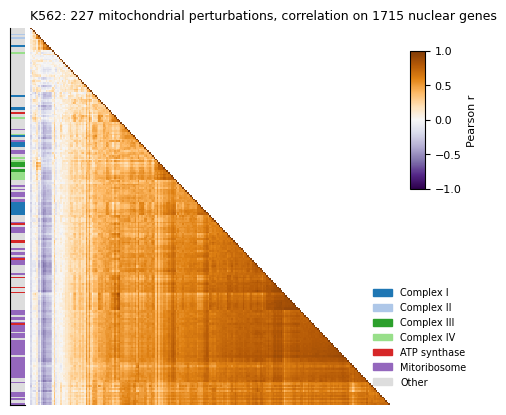

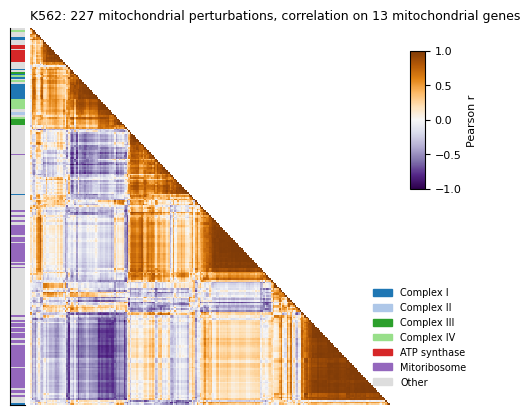

,nuclear (1715 genes),mitochondrial (13 genes)
Complex IV,0.51,0.84
Mitoribosome,0.68,0.58
Complex I,0.46,0.59
ATP synthase,0.70,0.93
Complex III,0.69,0.86


In [2]:
k562, k_sel, k_cats, k_sum = analyse("k562_gw", "K562", 50, ["fig12_k562_nuclear", "fig13_k562_mtdna"])
k_sum

RPE1: 132 mitochondrial perturbations


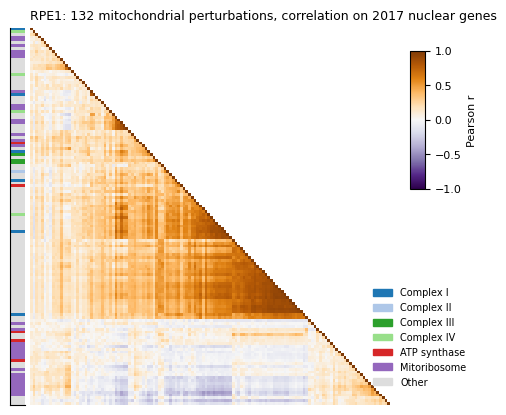

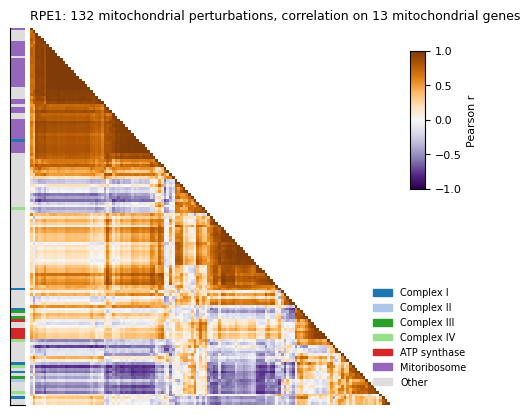

,nuclear (2017 genes),mitochondrial (13 genes)
Complex IV,0.12,0.44
Mitoribosome,0.10,0.86
Complex I,0.31,0.14
ATP synthase,0.07,0.89
Complex III,0.27,0.62


In [3]:
rpe1, r_sel, r_cats, r_sum = analyse("rpe1", "RPE1", 20, ["fig15_rpe1_nuclear", "fig16_rpe1_mtdna"])
r_sum

## Report Fig. 14: expression of the 13 mtDNA-encoded genes (K562; cf. paper Fig. 6D)

A representative subset, as in the paper: for each complex, the 8 perturbations with the strongest mtDNA
response (mean absolute z over the 13 genes), plus TMEM242. Columns are grouped by complex.

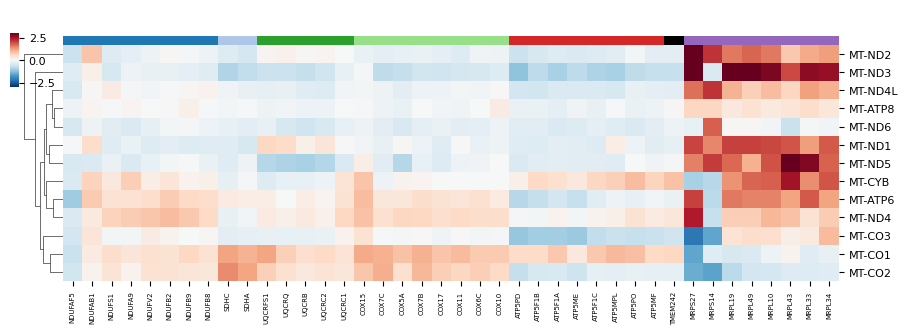

,MT-ND1,MT-ND2,MT-CO1,MT-CO2,MT-ATP8,MT-ATP6,MT-CO3,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB
ATP synthase,-0.19,-0.29,0.55,-0.34,-0.12,-0.38,-0.75,-0.67,-0.36,0.13,-0.20,-0.31,0.55
Complex I,-0.25,-0.06,0.24,0.17,0.03,0.35,-0.05,-0.20,0.05,0.50,-0.13,-0.13,0.18
Complex II,-0.43,-0.45,1.12,1.30,-0.06,0.25,-0.29,-0.82,-0.18,-0.17,-0.26,-0.28,-0.16
Complex III,0.35,0.07,0.68,0.45,-0.12,0.19,-0.15,-0.57,-0.27,0.30,-0.82,-0.41,-0.12
Complex IV,-0.13,-0.13,0.68,0.56,-0.03,0.36,-0.01,-0.36,-0.05,0.51,-0.14,-0.20,0.10
Mitoribosome,1.07,1.22,-0.67,-0.64,0.21,0.64,-0.27,1.26,0.60,0.42,0.57,0.05,0.58
TMEM242,-0.27,-0.32,0.63,-0.27,0.04,-0.20,-0.61,-0.68,-0.33,0.35,-0.07,-0.18,0.87


In [4]:
mt_ids = feature_sets(k562)["mitochondrial"]
o = k562.obs
pool = o.index[(o["num_cells_filtered"] >= 25) & (o["anderson_darling_counts"] >= 20) &
               (o["target"].map(category) != "Other") | (o["target"] == "TMEM242")]
mt_all = gwps.profiles(k562[pool], mt_ids)
cat_all = o.loc[pool, "target"].map(lambda g: "TMEM242" if g == "TMEM242" else category(g))
strength = mt_all.abs().mean(1)
cat_order = ["Complex I", "Complex II", "Complex III", "Complex IV", "ATP synthase", "TMEM242", "Mitoribosome"]
show = [i for k in cat_order for i in strength[cat_all == k].nlargest(8).index]
mt = mt_all.loc[show]
mt.index = o.loc[show, "target"].values
colors = {**palette, "TMEM242": "black"}
g = sns.clustermap(mt.T, cmap=gwps.EXPR_CMAP, center=0, vmin=-3, vmax=3, row_cluster=True, col_cluster=False,
                   col_colors=[colors[cat_all[i]] for i in show], xticklabels=True, yticklabels=True,
                   figsize=(9, 3.6), dendrogram_ratio=(0.05, 0.1), cbar_pos=(0.0, 0.75, 0.01, 0.15))
plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=5)
g.ax_heatmap.set_xlabel(""); g.ax_heatmap.set_ylabel("")
gwps.savefig(g.fig, "fig14_mtdna_genes_k562")
pd.DataFrame(mt_all.values, index=cat_all.values).groupby(level=0).mean().round(2).set_axis(mt_all.columns, axis=1)

## Report Fig. 17: TMEM242 resembles ATP synthase, not complex I, on the mtDNA-encoded genes (cf. paper Fig. 7D, S8G)

K562: TMEM242 vs ATP synthase r = 0.90, vs complex I r = 0.46 (1 TMEM242 perturbation(s), 38 in total)
RPE1: TMEM242 vs ATP synthase r = 0.72, vs complex I r = 0.21 (3 TMEM242 perturbation(s), 14 in total)


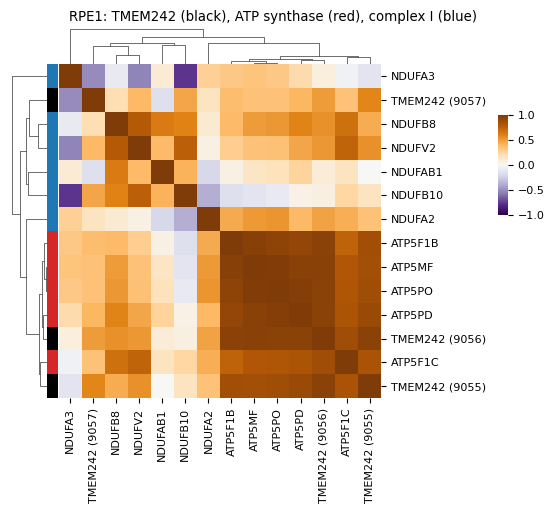

In [5]:
def tmem242(a, label, fig_name=None):
    o = a.obs
    sel = o.index[(o["target"].str.startswith(("ATP5", "NDUF")) | (o["target"] == "TMEM242")) &
                  (o["num_cells_filtered"] >= 25) & (o["anderson_darling_counts"] >= 20)]
    prof = gwps.profiles(a[sel], feature_sets(a)["mitochondrial"])
    t_ = o.loc[sel, "target"]
    prof.index = [f"{g} ({i.split('_')[0]})" if (t_ == g).sum() > 1 else g for i, g in zip(sel, t_)]
    c = pd.DataFrame(np.corrcoef(prof.values), index=prof.index, columns=prof.index)
    is_t = t_.values == "TMEM242"
    print(f"{label}: TMEM242 vs ATP synthase r = {c.values[is_t][:, t_.str.startswith('ATP5').values].mean():.2f}, "
          f"vs complex I r = {c.values[is_t][:, t_.str.startswith('NDUF').values].mean():.2f} "
          f"({is_t.sum()} TMEM242 perturbation(s), {len(prof)} in total)")
    if fig_name:
        colors = ["black" if g == "TMEM242" else palette[category(g)] for g in t_]
        g = sns.clustermap(c, method="average", cmap=gwps.CORR_CMAP, vmin=-1, vmax=1, row_colors=colors,
                           xticklabels=True, yticklabels=True, figsize=(5, 5), dendrogram_ratio=0.1,
                           cbar_pos=(1.0, 0.6, 0.02, 0.2))
        g.ax_heatmap.set_xlabel(""); g.ax_heatmap.set_ylabel("")
        g.fig.suptitle(f"{label}: TMEM242 (black), ATP synthase (red), complex I (blue)", x=0.55, y=1.01)
        gwps.savefig(g.fig, fig_name)

tmem242(k562, "K562")
tmem242(rpe1, "RPE1", "fig17_tmem242_rpe1")